In [1]:
# =========================================================
# INSTALL REQUIRED LIBRARIES
# =========================================================

!pip install -q torch scikit-learn pandas numpy tqdm joblib matplotlib

In [2]:
# =========================================================
# IMPORTS
# =========================================================

import os
import json
import random
import warnings

warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd

from tqdm import tqdm

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import (
    Dataset,
    DataLoader,
    TensorDataset
)

# =========================================================
# REPRODUCIBILITY
# =========================================================

SEED = 42

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)

torch.cuda.manual_seed_all(SEED)

# =========================================================
# DEVICE
# =========================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(f"Using Device: {DEVICE}")

Using Device: cuda


In [3]:
# =========================================================
# LOAD DATASET
# =========================================================

from google.colab import files

uploaded = files.upload()

DATASET_PATH = list(uploaded.keys())[0]

df = pd.read_csv(DATASET_PATH)

print(df.shape)

df.head()

Saving HCHE_PHYSICS_GUIDED_DATASET.csv to HCHE_PHYSICS_GUIDED_DATASET.csv
(82054, 49)


,time,T_hot_in,T_cold_in,m_dot_hot,m_dot_cold,rho_hot,rho_cold,mu_hot,mu_cold,cp_hot,...,NTU,effectiveness,Q_dot,T_hot_out,T_cold_out,f_hot,f_cold,deltaP_hot,deltaP_cold,deltaP_total
0,2093.142790,76.604672,29.808486,0.345828,0.554962,996.632954,992.389186,0.000461,0.000510,4045.075649,...,5.040812,0.942139,60851.283504,32.361214,56.082917,0.019451,0.044912,34125.196165,0.961226,31278.016497
1,4841.725165,75.589884,20.248859,0.478148,0.385256,988.832675,997.558945,0.000405,0.000553,4189.194586,...,8.000000,0.957797,83400.803040,34.519313,73.018159,0.018033,0.053218,35315.516184,0.042229,37250.838081
2,764.212069,72.019348,34.761618,0.918789,0.547025,987.174533,990.754050,0.000899,0.000538,3931.584705,...,3.196681,0.861614,72482.365496,51.896271,66.409385,0.017229,0.040682,225669.936855,0.316054,222236.439604
3,2765.754268,74.885166,26.741992,0.556500,0.889022,989.383351,995.745766,0.000830,0.000724,4121.566781,...,4.887954,0.927474,104701.982905,30.280649,56.019304,0.019808,0.044648,120729.463572,5.842062,120966.537648
4,2561.130256,74.917768,34.049986,0.815052,0.738648,993.410855,992.197246,0.000823,0.000495,3968.328114,...,4.049571,0.839848,101609.366835,44.820108,68.445152,0.018435,0.040239,107793.531231,4.446542,107291.670449


In [4]:
print(df.columns.tolist())

['time', 'T_hot_in', 'T_cold_in', 'm_dot_hot', 'm_dot_cold', 'rho_hot', 'rho_cold', 'mu_hot', 'mu_cold', 'cp_hot', 'cp_cold', 'k_hot', 'k_cold', 'tube_diameter', 'coil_diameter', 'coil_pitch', 'num_turns', 'shell_diameter', 'coil_length', 'tube_cross_area', 'tube_surface_area', 'shell_cross_area', 'pitch_ratio', 'velocity_hot', 'velocity_cold', 'hydraulic_diameter', 'Re_hot', 'Re_cold', 'Pr_hot', 'Pr_cold', 'Dean_number', 'C_hot', 'C_cold', 'C_min', 'C_max', 'C_ratio', 'Nu', 'h_hot', 'h_cold', 'NTU', 'effectiveness', 'Q_dot', 'T_hot_out', 'T_cold_out', 'f_hot', 'f_cold', 'deltaP_hot', 'deltaP_cold', 'deltaP_total']


In [5]:
# =========================================================
# FULL COLUMN STANDARDIZATION
# DATASET -> STREAMLIT/TRAINING FORMAT
# =========================================================

rename_map = {

    # =====================================================
    # TIME
    # =====================================================

    "time":
        "time_s",

    # =====================================================
    # TEMPERATURES
    # =====================================================

    "T_hot_in":
        "hot_inlet_temp_C",

    "T_cold_in":
        "cold_inlet_temp_C",

    "T_hot_out":
        "T_hot_out",

    "T_cold_out":
        "T_cold_out",

    # =====================================================
    # MASS FLOW
    # =====================================================

    "m_dot_hot":
        "hot_mass_flow_kg_s",

    "m_dot_cold":
        "cold_mass_flow_kg_s",

    # =====================================================
    # DENSITY
    # =====================================================

    "rho_hot":
        "hot_density_kg_m3",

    "rho_cold":
        "cold_density_kg_m3",

    # =====================================================
    # VISCOSITY
    # =====================================================

    "mu_hot":
        "hot_viscosity_Pa_s",

    "mu_cold":
        "cold_viscosity_Pa_s",

    # =====================================================
    # SPECIFIC HEAT
    # =====================================================

    "cp_hot":
        "hot_specific_heat_J_kgK",

    "cp_cold":
        "cold_specific_heat_J_kgK",

    # =====================================================
    # THERMAL CONDUCTIVITY
    # =====================================================

    "k_hot":
        "hot_thermal_conductivity_W_mK",

    "k_cold":
        "cold_thermal_conductivity_W_mK",

    # =====================================================
    # GEOMETRY
    # =====================================================

    "tube_diameter":
        "tube_diameter_m",

    "coil_diameter":
        "coil_diameter_m",

    "coil_pitch":
        "coil_pitch_m",

    "num_turns":
        "number_of_turns",

    "shell_diameter":
        "shell_diameter_m",

    # =====================================================
    # PRECOMPUTED GEOMETRIC FEATURES
    # =====================================================

    "coil_length":
        "coil_length_m",

    "tube_cross_area":
        "tube_cross_section_area_m2",

    "tube_surface_area":
        "tube_surface_area_m2",

    "shell_cross_area":
        "shell_cross_section_area_m2",

    "hydraulic_diameter":
        "hydraulic_diameter_m",

    # =====================================================
    # VELOCITIES
    # =====================================================

    "velocity_hot":
        "hot_velocity_m_s",

    "velocity_cold":
        "cold_velocity_m_s",

    # =====================================================
    # FLOW NUMBERS
    # =====================================================

    "Re_hot":
        "re_hot",

    "Re_cold":
        "re_cold",

    "Dean_number":
        "dean_number",

    # =====================================================
    # CAPACITY RATES
    # =====================================================

    "C_hot":
        "hot_heat_capacity_rate_W_K",

    "C_cold":
        "cold_heat_capacity_rate_W_K",

    "C_min":
        "c_min_W_K",

    "C_max":
        "c_max_W_K",

    "C_ratio":
        "capacity_ratio",

    # =====================================================
    # PRANDTL
    # =====================================================

    "Pr_hot":
        "pr_hot",

    "Pr_cold":
        "pr_cold",

    # =====================================================
    # TARGETS
    # =====================================================

    "deltaP_total":
        "pressure_drop_total_Pa",

    "U_overall":
        "overall_heat_transfer_coefficient_U_W_m2K"
}

# =========================================================
# APPLY RENAME
# =========================================================

df.rename(
    columns=rename_map,
    inplace=True
)

# =========================================================
# VERIFY IMPORTANT COLUMNS
# =========================================================

required_columns = [

    "tube_diameter_m",
    "coil_diameter_m",
    "coil_pitch_m",
    "number_of_turns",
    "shell_diameter_m",

    "hot_mass_flow_kg_s",
    "cold_mass_flow_kg_s",

    "hot_density_kg_m3",
    "cold_density_kg_m3",

    "hot_viscosity_Pa_s",
    "cold_viscosity_Pa_s",

    "hot_specific_heat_J_kgK",
    "cold_specific_heat_J_kgK"
]

missing_cols = [
    col for col in required_columns
    if col not in df.columns
]

if len(missing_cols) > 0:

    print("MISSING COLUMNS:")
    print(missing_cols)

else:

    print("All Required Columns Present")

print("\nTotal Columns:")
print(len(df.columns))

All Required Columns Present

Total Columns:
49


In [6]:
# =========================================================
# FEATURE ENGINEERING
# =========================================================

EPS = 1e-12


def compute_derived_features(df):

    d = df["tube_diameter_m"]

    D_coil = df["coil_diameter_m"]

    p = df["coil_pitch_m"]

    N = df["number_of_turns"]

    D_shell = df["shell_diameter_m"]

    rho_h = df["hot_density_kg_m3"]

    rho_c = df["cold_density_kg_m3"]

    mu_h = df["hot_viscosity_Pa_s"]

    mu_c = df["cold_viscosity_Pa_s"]

    m_h = df["hot_mass_flow_kg_s"]

    m_c = df["cold_mass_flow_kg_s"]

    # =====================================================
    # GEOMETRY
    # =====================================================

    coil_length_m = (
        N *
        np.sqrt(
            (np.pi * D_coil)**2 +
            p**2
        )
    )

    tube_cross_section_area_m2 = (
        np.pi * d**2 / 4
    )

    tube_surface_area_m2 = (
        np.pi * d * coil_length_m
    )

    shell_cross_section_area_m2 = (
        np.pi *
        (
            D_shell**2 -
            D_coil**2
        ) / 4
    )

    hydraulic_diameter_m = (
        D_shell - D_coil
    )

    # =====================================================
    # VELOCITIES
    # =====================================================

    hot_velocity_m_s = (
        m_h /
        (
            rho_h *
            tube_cross_section_area_m2 +
            EPS
        )
    )

    cold_velocity_m_s = (
        m_c /
        (
            rho_c *
            shell_cross_section_area_m2 +
            EPS
        )
    )

    # =====================================================
    # REYNOLDS NUMBERS
    # =====================================================

    re_hot = (
        rho_h *
        hot_velocity_m_s *
        d
    ) / (mu_h + EPS)

    re_cold = (
        rho_c *
        cold_velocity_m_s *
        hydraulic_diameter_m
    ) / (mu_c + EPS)

    # =====================================================
    # DEAN NUMBER
    # =====================================================

    dean_number = (
        re_hot *
        np.sqrt(
            d / (D_coil + EPS)
        )
    )

    # =====================================================
    # ADDITIONAL FEATURES
    # =====================================================

    pitch_ratio = (
        p / (D_coil + EPS)
    )

    curvature_ratio = (
        d / (D_coil + EPS)
    )

    hot_heat_capacity_rate_W_K = (
        m_h *
        df["hot_specific_heat_J_kgK"]
    )

    cold_heat_capacity_rate_W_K = (
        m_c *
        df["cold_specific_heat_J_kgK"]
    )

    c_min_W_K = np.minimum(
        hot_heat_capacity_rate_W_K,
        cold_heat_capacity_rate_W_K
    )

    c_max_W_K = np.maximum(
        hot_heat_capacity_rate_W_K,
        cold_heat_capacity_rate_W_K
    )

    capacity_ratio = (
        c_min_W_K /
        (c_max_W_K + EPS)
    )

    derived = pd.DataFrame({

        "coil_length_m":
            coil_length_m,

        "tube_cross_section_area_m2":
            tube_cross_section_area_m2,

        "tube_surface_area_m2":
            tube_surface_area_m2,

        "shell_cross_section_area_m2":
            shell_cross_section_area_m2,

        "pitch_ratio":
            pitch_ratio,

        "curvature_ratio":
            curvature_ratio,

        "hydraulic_diameter_m":
            hydraulic_diameter_m,

        "hot_velocity_m_s":
            hot_velocity_m_s,

        "cold_velocity_m_s":
            cold_velocity_m_s,

        "re_hot":
            re_hot,

        "re_cold":
            re_cold,

        "dean_number":
            dean_number,

        "hot_heat_capacity_rate_W_K":
            hot_heat_capacity_rate_W_K,

        "cold_heat_capacity_rate_W_K":
            cold_heat_capacity_rate_W_K,

        "c_min_W_K":
            c_min_W_K,

        "c_max_W_K":
            c_max_W_K,

        "capacity_ratio":
            capacity_ratio
    })

    return derived

In [7]:
# =========================================================
# REMOVE OLD DERIVED FEATURES
# =========================================================

DERIVED_FEATURES = [

    "coil_length_m",

    "tube_cross_section_area_m2",

    "tube_surface_area_m2",

    "shell_cross_section_area_m2",

    "pitch_ratio",

    "curvature_ratio",

    "hydraulic_diameter_m",

    "hot_velocity_m_s",

    "cold_velocity_m_s",

    "re_hot",

    "re_cold",

    "dean_number",

    "hot_heat_capacity_rate_W_K",

    "cold_heat_capacity_rate_W_K",

    "c_min_W_K",

    "c_max_W_K",

    "capacity_ratio"
]

existing_cols_to_drop = [

    col for col in DERIVED_FEATURES

    if col in df.columns
]

df.drop(

    columns=existing_cols_to_drop,

    inplace=True,

    errors="ignore"
)

# =========================================================
# RECOMPUTE DERIVED FEATURES
# =========================================================

derived_df = compute_derived_features(df)

# =========================================================
# FINAL DATAFRAME
# =========================================================

full_df = pd.concat(

    [df, derived_df],

    axis=1
)

# =========================================================
# GENERATE OVERALL U TARGET
# =========================================================

EPS = 1e-12

full_df[
    "overall_heat_transfer_coefficient_U_W_m2K"
] = 1.0 / (

    (1.0 / (full_df["h_hot"] + EPS))

    +

    (1.0 / (full_df["h_cold"] + EPS))
)

# =========================================================
# RAW INPUT FEATURES
# =========================================================

RAW_INPUT_FEATURES = [

    "time_s",

    "hot_inlet_temp_C",
    "cold_inlet_temp_C",

    "hot_mass_flow_kg_s",
    "cold_mass_flow_kg_s",

    "hot_density_kg_m3",
    "cold_density_kg_m3",

    "hot_viscosity_Pa_s",
    "cold_viscosity_Pa_s",

    "hot_specific_heat_J_kgK",
    "cold_specific_heat_J_kgK",

    "hot_thermal_conductivity_W_mK",
    "cold_thermal_conductivity_W_mK",

    "tube_diameter_m",

    "coil_diameter_m",

    "coil_pitch_m",

    "number_of_turns",

    "shell_diameter_m",

    "pr_hot",
    "pr_cold"
]

# =========================================================
# FINAL INPUT FEATURES
# =========================================================

INPUT_FEATURES = (

    RAW_INPUT_FEATURES +

    DERIVED_FEATURES
)

# =========================================================
# TARGET FEATURES
# =========================================================

TARGET_FEATURES = [

    "effectiveness",

    "pressure_drop_total_Pa",

    "overall_heat_transfer_coefficient_U_W_m2K"
]

# =========================================================
# VALIDATION
# =========================================================

missing_inputs = [

    col for col in INPUT_FEATURES

    if col not in full_df.columns
]

missing_targets = [

    col for col in TARGET_FEATURES

    if col not in full_df.columns
]

if len(missing_inputs) > 0:

    raise ValueError(

        f"Missing Input Features: {missing_inputs}"
    )

if len(missing_targets) > 0:

    raise ValueError(

        f"Missing Targets: {missing_targets}"
    )

# =========================================================
# FINAL VALIDATION
# =========================================================

print("=" * 60)

print("ALL FEATURES VALIDATED")

print("=" * 60)

print(f"Raw Features: {len(RAW_INPUT_FEATURES)}")

print(f"Derived Features: {len(DERIVED_FEATURES)}")

print(f"Total Input Features: {len(INPUT_FEATURES)}")

print(f"Total Targets: {len(TARGET_FEATURES)}")

print("=" * 60)

assert len(INPUT_FEATURES) == 37

assert len(TARGET_FEATURES) == 3

print("Feature count validation passed.")

ALL FEATURES VALIDATED
Raw Features: 20
Derived Features: 17
Total Input Features: 37
Total Targets: 3
Feature count validation passed.


In [8]:
print(TARGET_FEATURES)

print(len(TARGET_FEATURES))

['effectiveness', 'pressure_drop_total_Pa', 'overall_heat_transfer_coefficient_U_W_m2K']
3


In [9]:
# =========================================================
# DATA VALIDATION
# =========================================================

# Get the list of actual columns in full_df
existing_full_df_columns = full_df.columns.tolist()

# Filter TARGET_FEATURES to only include columns present in full_df
present_target_features = [col for col in TARGET_FEATURES if col in existing_full_df_columns]

if len(present_target_features) < len(TARGET_FEATURES):
    missing_targets = [col for col in TARGET_FEATURES if col not in existing_full_df_columns]
    print(f"Warning: The following target features are missing from full_df: {missing_targets}")
    print("Proceeding with available target features for validation.")

# Use the filtered list for validation
print(full_df[INPUT_FEATURES].isnull().sum().sum())

# Use the filtered list for validation
print(full_df[present_target_features].isnull().sum().sum())

print(np.isinf(full_df[INPUT_FEATURES]).sum().sum())

# Use the filtered list for validation
print(np.isinf(full_df[present_target_features]).sum().sum())

print(full_df.shape)

0
0
0
0
(82054, 51)


In [10]:
# =========================================================
# SPLIT FEATURES/TARGETS
# =========================================================

# Update TARGET_FEATURES to only include columns that are actually present in full_df
# This was identified in the previous cell's execution as 'present_target_features'


X = full_df[INPUT_FEATURES].values.astype(np.float32)

y = full_df[TARGET_FEATURES].values.astype(np.float32)

# =========================================================
# TRAIN TEST SPLIT
# =========================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED
)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

# =========================================================
# SCALERS
# =========================================================

x_scaler = StandardScaler()

y_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train)

X_val_scaled = x_scaler.transform(X_val)

X_test_scaled = x_scaler.transform(X_test)

y_train_scaled = y_scaler.fit_transform(y_train)

y_val_scaled = y_scaler.transform(y_val)

y_test_scaled = y_scaler.transform(y_test)

# =========================================================
# SAVE SCALERS
# =========================================================

joblib.dump(
    x_scaler,
    "x_scaler.pkl"
)

joblib.dump(
    y_scaler,
    "y_scaler.pkl"
)

print("Scalers Saved")

(65643, 37)
(8205, 37)
(8206, 37)
Scalers Saved


In [11]:
# =========================================================
# TORCH TENSORS
# =========================================================

X_train_tensor = torch.tensor(
    X_train_scaled,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train_scaled,
    dtype=torch.float32
)

X_val_tensor = torch.tensor(
    X_val_scaled,
    dtype=torch.float32
)

y_val_tensor = torch.tensor(
    y_val_scaled,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_scaled,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test_scaled,
    dtype=torch.float32
)

# =========================================================
# DATASETS
# =========================================================

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

# =========================================================
# DATALOADERS
# =========================================================

BATCH_SIZE = 512

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("DataLoaders Ready")

DataLoaders Ready


In [12]:
# =========================================================
# METRICS
# =========================================================

def regression_metrics(y_true, y_pred):

    results = {}

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    mape = np.mean(
        np.abs(
            (y_true - y_pred)
            /
            (np.abs(y_true) + 1e-8)
        )
    ) * 100

    results["RMSE"] = rmse

    results["MAE"] = mae

    results["R2"] = r2

    results["MAPE"] = mape

    return results

In [13]:
# =========================================================
# SHARED TRAINING ENGINE
# =========================================================

class EarlyStopping:

    def __init__(
        self,
        patience=20,
        min_delta=1e-5
    ):

        self.patience = patience

        self.min_delta = min_delta

        self.best_loss = np.inf

        self.counter = 0

        self.stop = False

    def __call__(self, val_loss):

        if val_loss < (
            self.best_loss -
            self.min_delta
        ):

            self.best_loss = val_loss

            self.counter = 0

        else:

            self.counter += 1

            if self.counter >= self.patience:

                self.stop = True


# =========================================================
# TRAIN FUNCTION
# =========================================================

def train_model(

    model,

    train_loader,

    val_loader,

    optimizer,

    criterion,

    epochs=200,

    model_name="model"

):

    history = {

        "train_loss": [],
        "val_loss": []
    }

    early_stopping = EarlyStopping(
        patience=25
    )

    best_val_loss = np.inf

    model.to(DEVICE)

    for epoch in range(epochs):

        # =================================================
        # TRAIN
        # =================================================

        model.train()

        train_losses = []

        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(DEVICE)

            y_batch = y_batch.to(DEVICE)

            optimizer.zero_grad()

            predictions = model(X_batch)

            loss = criterion(
                predictions,
                y_batch
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            optimizer.step()

            train_losses.append(
                loss.item()
            )

        avg_train_loss = np.mean(
            train_losses
        )

        # =================================================
        # VALIDATION
        # =================================================

        model.eval()

        val_losses = []

        with torch.no_grad():

            for X_batch, y_batch in val_loader:

                X_batch = X_batch.to(DEVICE)

                y_batch = y_batch.to(DEVICE)

                predictions = model(X_batch)

                loss = criterion(
                    predictions,
                    y_batch
                )

                val_losses.append(
                    loss.item()
                )

        avg_val_loss = np.mean(
            val_losses
        )

        history["train_loss"].append(
            avg_train_loss
        )

        history["val_loss"].append(
            avg_val_loss
        )

        # =================================================
        # SAVE BEST
        # =================================================

        if avg_val_loss < best_val_loss:

            best_val_loss = avg_val_loss

            torch.save(
                model.state_dict(),
                f"{model_name}.pth"
            )

        # =================================================
        # LOGGING
        # =================================================

        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train Loss: {avg_train_loss:.6f} | "
            f"Val Loss: {avg_val_loss:.6f}"
        )

        # =================================================
        # EARLY STOPPING
        # =================================================

        early_stopping(avg_val_loss)

        if early_stopping.stop:

            print("Early stopping triggered")

            break

    return history

In [14]:
# =========================================================
# EXPORT CONFIG
# =========================================================

model_config = {

    "input_features":
        INPUT_FEATURES,

    "target_features":
        TARGET_FEATURES,

    "input_dim":
        len(INPUT_FEATURES),

    "output_dim":
        len(TARGET_FEATURES),

    "mlp_hidden_dims":
        [256, 256, 128],

    "dropout":
        0.10
}

with open(
    "model_config.json",
    "w"
) as f:

    json.dump(
        model_config,
        f,
        indent=4
    )

print("model_config.json saved")

model_config.json saved


# **Phase 2 Starts**

## MLP

In [15]:
# =========================================================
# ADVANCED MLP REGRESSOR
# =========================================================

class MLPRegressor(nn.Module):

    def __init__(

        self,

        input_dim,

        output_dim,

        hidden_dims=[512, 256, 128],

        dropout=0.15

    ):

        super().__init__()

        layers = []

        prev_dim = input_dim

        # =================================================
        # HIDDEN BLOCKS
        # =================================================

        for hidden_dim in hidden_dims:

            layers.extend([

                nn.Linear(
                    prev_dim,
                    hidden_dim
                ),

                nn.BatchNorm1d(
                    hidden_dim
                ),

                nn.GELU(),

                nn.Dropout(
                    dropout
                )
            ])

            prev_dim = hidden_dim

        # =================================================
        # OUTPUT LAYER
        # =================================================

        layers.append(

            nn.Linear(
                prev_dim,
                output_dim
            )
        )

        self.network = nn.Sequential(
            *layers
        )

        # =================================================
        # WEIGHT INIT
        # =================================================

        self._initialize_weights()

    # =====================================================
    # INITIALIZATION
    # =====================================================

    def _initialize_weights(self):

        for module in self.modules():

            if isinstance(
                module,
                nn.Linear
            ):

                nn.init.kaiming_normal_(
                    module.weight
                )

                nn.init.zeros_(
                    module.bias
                )

    # =====================================================
    # FORWARD
    # =====================================================

    def forward(self, x):

        return self.network(x)

In [16]:
# =========================================================
# MODEL INITIALIZATION
# =========================================================

INPUT_DIM = len(INPUT_FEATURES)

OUTPUT_DIM = len(TARGET_FEATURES)

mlp_model = MLPRegressor(

    input_dim=INPUT_DIM,

    output_dim=OUTPUT_DIM,

    hidden_dims=[512, 256, 128],

    dropout=0.15

).to(DEVICE)

print(mlp_model)

MLPRegressor(
  (network): Sequential(
    (0): Linear(in_features=37, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.15, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): GELU(approximate='none')
    (7): Dropout(p=0.15, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): GELU(approximate='none')
    (11): Dropout(p=0.15, inplace=False)
    (12): Linear(in_features=128, out_features=3, bias=True)
  )
)


In [17]:
# =========================================================
# LOSS FUNCTION
# =========================================================

criterion = nn.HuberLoss(
    delta=1.0
)

# =========================================================
# OPTIMIZER
# =========================================================

optimizer = optim.AdamW(

    mlp_model.parameters(),

    lr=1e-3,

    weight_decay=1e-4
)

# =========================================================
# LEARNING RATE SCHEDULER
# =========================================================

scheduler = optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode="min",

    factor=0.5,

    patience=8
)

In [18]:
# =========================================================
# ADVANCED TRAINING ENGINE
# =========================================================

def train_model(

    model,

    train_loader,

    val_loader,

    optimizer,

    criterion,

    scheduler=None,

    epochs=200,

    model_name="model"

):

    history = {

        "train_loss": [],
        "val_loss": []
    }

    early_stopping = EarlyStopping(
        patience=25
    )

    best_val_loss = np.inf

    model.to(DEVICE)

    # =====================================================
    # EPOCH LOOP
    # =====================================================

    for epoch in range(epochs):

        # =================================================
        # TRAINING
        # =================================================

        model.train()

        train_losses = []

        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(DEVICE)

            y_batch = y_batch.to(DEVICE)

            optimizer.zero_grad()

            predictions = model(X_batch)

            loss = criterion(
                predictions,
                y_batch
            )

            loss.backward()

            # =============================================
            # GRADIENT CLIPPING
            # =============================================

            torch.nn.utils.clip_grad_norm_(

                model.parameters(),

                max_norm=1.0
            )

            optimizer.step()

            train_losses.append(
                loss.item()
            )

        avg_train_loss = np.mean(
            train_losses
        )

        # =================================================
        # VALIDATION
        # =================================================

        model.eval()

        val_losses = []

        with torch.no_grad():

            for X_batch, y_batch in val_loader:

                X_batch = X_batch.to(DEVICE)

                y_batch = y_batch.to(DEVICE)

                predictions = model(X_batch)

                loss = criterion(
                    predictions,
                    y_batch
                )

                val_losses.append(
                    loss.item()
                )

        avg_val_loss = np.mean(
            val_losses
        )

        # =================================================
        # SCHEDULER
        # =================================================

        if scheduler is not None:

            scheduler.step(
                avg_val_loss
            )

        # =================================================
        # SAVE HISTORY
        # =================================================

        history["train_loss"].append(
            avg_train_loss
        )

        history["val_loss"].append(
            avg_val_loss
        )

        # =================================================
        # SAVE BEST MODEL
        # =================================================

        if avg_val_loss < best_val_loss:

            best_val_loss = avg_val_loss

            torch.save(

                model.state_dict(),

                f"{model_name}.pth"
            )

            print(
                f"BEST MODEL SAVED "
                f"(Val Loss: {best_val_loss:.6f})"
            )

        # =================================================
        # CURRENT LR
        # =================================================

        current_lr = optimizer.param_groups[0]["lr"]

        # =================================================
        # LOGGING
        # =================================================

        print(

            f"Epoch [{epoch+1}/{epochs}] | "

            f"Train Loss: {avg_train_loss:.6f} | "

            f"Val Loss: {avg_val_loss:.6f} | "

            f"LR: {current_lr:.8f}"
        )

        # =================================================
        # EARLY STOPPING
        # =================================================

        early_stopping(avg_val_loss)

        if early_stopping.stop:

            print("\nEarly stopping triggered")

            break

    return history

In [19]:
# =========================================================
# TRAIN MLP MODEL
# =========================================================

mlp_history = train_model(

    model=mlp_model,

    train_loader=train_loader,

    val_loader=val_loader,

    optimizer=optimizer,

    criterion=criterion,

    scheduler=scheduler,

    epochs=150,

    model_name="mlp_model"
)

BEST MODEL SAVED (Val Loss: 0.010119)
Epoch [1/150] | Train Loss: 0.114106 | Val Loss: 0.010119 | LR: 0.00100000
BEST MODEL SAVED (Val Loss: 0.006939)
Epoch [2/150] | Train Loss: 0.040154 | Val Loss: 0.006939 | LR: 0.00100000
BEST MODEL SAVED (Val Loss: 0.005233)
Epoch [3/150] | Train Loss: 0.026300 | Val Loss: 0.005233 | LR: 0.00100000
BEST MODEL SAVED (Val Loss: 0.004765)
Epoch [4/150] | Train Loss: 0.020961 | Val Loss: 0.004765 | LR: 0.00100000
BEST MODEL SAVED (Val Loss: 0.004403)
Epoch [5/150] | Train Loss: 0.018650 | Val Loss: 0.004403 | LR: 0.00100000
BEST MODEL SAVED (Val Loss: 0.003791)
Epoch [6/150] | Train Loss: 0.016620 | Val Loss: 0.003791 | LR: 0.00100000
BEST MODEL SAVED (Val Loss: 0.003657)
Epoch [7/150] | Train Loss: 0.015434 | Val Loss: 0.003657 | LR: 0.00100000
Epoch [8/150] | Train Loss: 0.014611 | Val Loss: 0.004168 | LR: 0.00100000
BEST MODEL SAVED (Val Loss: 0.003392)
Epoch [9/150] | Train Loss: 0.014075 | Val Loss: 0.003392 | LR: 0.00100000
BEST MODEL SAVED (Val

In [20]:
# =========================================================
# LOAD BEST SAVED MODEL
# =========================================================

best_mlp = MLPRegressor(

    input_dim=INPUT_DIM,

    output_dim=OUTPUT_DIM,

    hidden_dims=[512, 256, 128],

    dropout=0.15

).to(DEVICE)

best_mlp.load_state_dict(

    torch.load(
        "mlp_model.pth"
    )
)

best_mlp.eval()

print("Best MLP model loaded successfully")

Best MLP model loaded successfully


In [21]:
# =========================================================
# GENERATE TEST PREDICTIONS
# =========================================================

all_predictions = []

all_targets = []

best_mlp.eval()

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(DEVICE)

        predictions = best_mlp(X_batch)

        all_predictions.append(

            predictions.cpu().numpy()
        )

        all_targets.append(

            y_batch.cpu().numpy()
        )

# =========================================================
# CONCATENATE
# =========================================================

all_predictions = np.vstack(
    all_predictions
)

all_targets = np.vstack(
    all_targets
)

print(all_predictions.shape)

print(all_targets.shape)

(8206, 3)
(8206, 3)


In [22]:
# =========================================================
# INVERSE TRANSFORM
# =========================================================

all_predictions_inv = y_scaler.inverse_transform(
    all_predictions
)

all_targets_inv = y_scaler.inverse_transform(
    all_targets
)

print("Inverse scaling complete")

Inverse scaling complete


In [23]:
# =========================================================
# METRIC FUNCTIONS
# =========================================================

from sklearn.metrics import (

    mean_absolute_error,

    mean_squared_error,

    r2_score
)

def regression_metrics(

    y_true,

    y_pred
):

    mae = mean_absolute_error(

        y_true,
        y_pred
    )

    mse = mean_squared_error(

        y_true,
        y_pred
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(

        y_true,
        y_pred
    )

    # =====================================================
    # SAFE MAPE
    # =====================================================

    eps = 1e-8

    mape = np.mean(

        np.abs(

            (y_true - y_pred) /

            (np.abs(y_true) + eps)
        )

    ) * 100

    return {

        "MAE": mae,

        "MSE": mse,

        "RMSE": rmse,

        "R2": r2,

        "MAPE": mape
    }

In [24]:
# =========================================================
# OVERALL METRICS
# =========================================================

overall_metrics = regression_metrics(

    all_targets_inv,

    all_predictions_inv
)

print("\n")

print("=" * 60)

print("MLP OVERALL TEST METRICS")

print("=" * 60)

for metric_name, metric_value in overall_metrics.items():

    print(

        f"{metric_name}: "
        f"{metric_value:.6f}"
    )



MLP OVERALL TEST METRICS
MAE: 1241.874634
MSE: 18165546.000000
RMSE: 4262.105818
R2: 0.996269
MAPE: 3.012911


In [25]:
# =========================================================
# TARGET WISE METRICS
# =========================================================

target_metrics = []

for i, target_name in enumerate(TARGET_FEATURES):

    y_true_i = all_targets_inv[:, i]

    y_pred_i = all_predictions_inv[:, i]

    metrics_i = regression_metrics(

        y_true_i,

        y_pred_i
    )

    target_metrics.append({

        "Target": target_name,

        "MAE": metrics_i["MAE"],

        "RMSE": metrics_i["RMSE"],

        "R2": metrics_i["R2"],

        "MAPE": metrics_i["MAPE"]
    })

metrics_df = pd.DataFrame(
    target_metrics
)

print("\n")

print(metrics_df)

metrics_df



                                      Target          MAE         RMSE  \
0                              effectiveness     0.005668     0.007628   
1                     pressure_drop_total_Pa  3627.871094  7380.834912   
2  overall_heat_transfer_coefficient_U_W_m2K    97.734840   141.727973   

         R2      MAPE  
0  0.992680  0.677067  
1  0.997425  6.631345  
2  0.998700  1.730320  


,Target,MAE,RMSE,R2,MAPE
0,effectiveness,0.005668,0.007628,0.992680,0.677067
1,pressure_drop_total_Pa,3627.871094,7380.834912,0.997425,6.631345
2,overall_heat_transfer_coefficient_U_W_m2K,97.734840,141.727973,0.998700,1.730320


In [26]:
# =========================================================
# SAVE METRICS CSV
# =========================================================

metrics_df.to_csv(

    "mlp_metrics.csv",

    index=False
)

print("Metrics CSV saved")

Metrics CSV saved


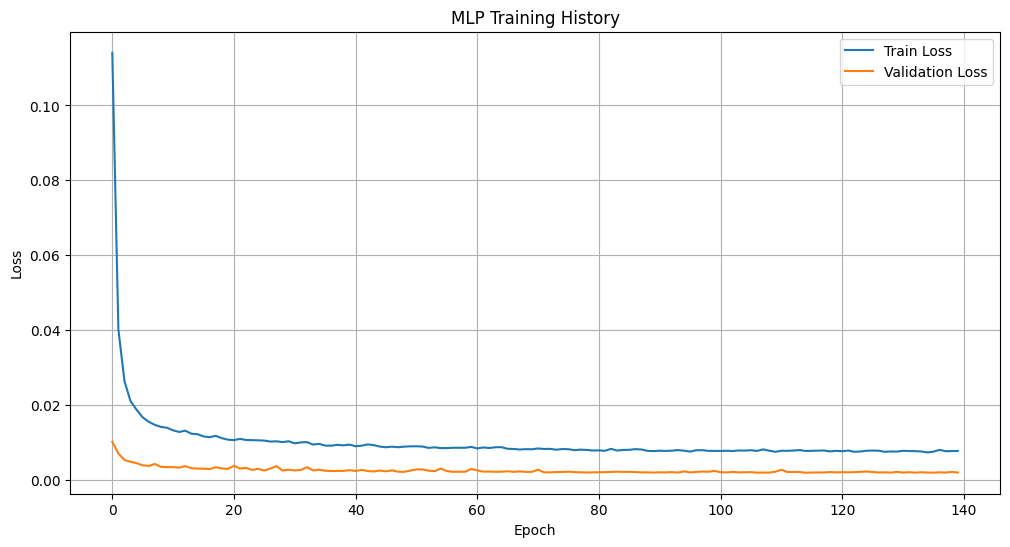

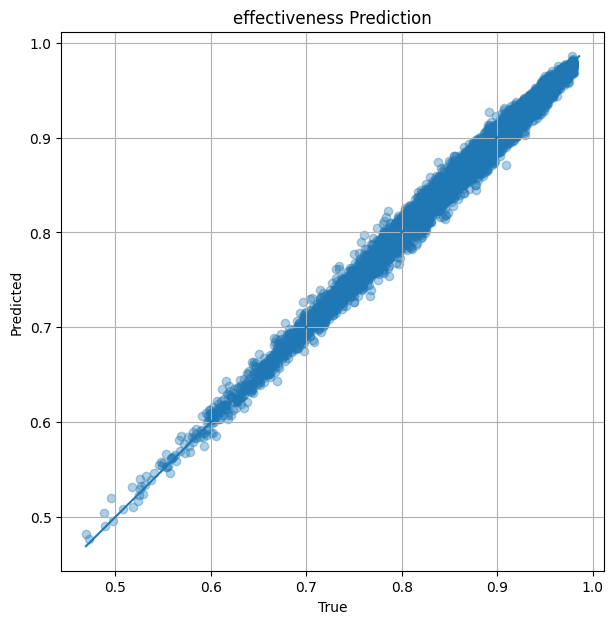

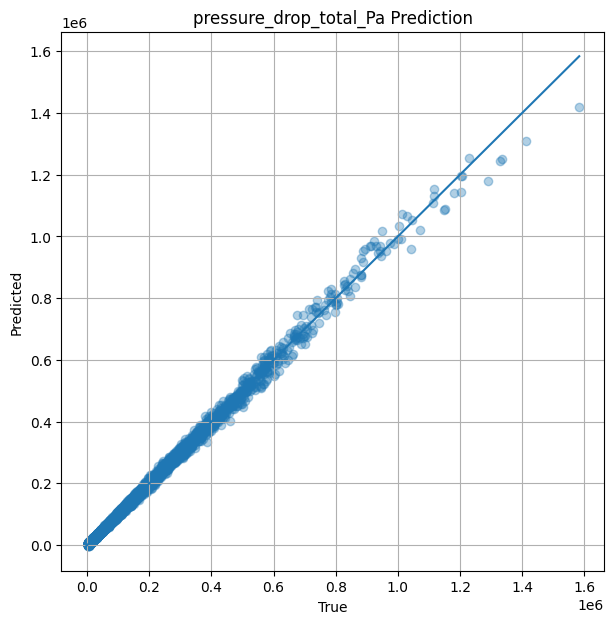

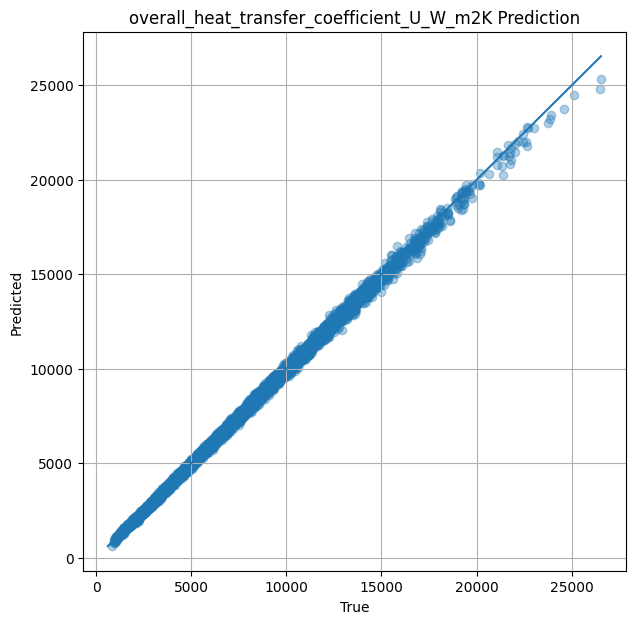

In [27]:
# =========================================================
# TRAINING CURVE
# =========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(

    mlp_history["train_loss"],

    label="Train Loss"
)

plt.plot(

    mlp_history["val_loss"],

    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("MLP Training History")

plt.legend()

plt.grid(True)

plt.show()


# =========================================================
# PREDICTED VS TRUE
# =========================================================

for i, target_name in enumerate(TARGET_FEATURES):

    plt.figure(figsize=(7,7))

    plt.scatter(

        all_targets_inv[:, i],

        all_predictions_inv[:, i],

        alpha=0.35
    )

    min_val = min(

        all_targets_inv[:, i].min(),

        all_predictions_inv[:, i].min()
    )

    max_val = max(

        all_targets_inv[:, i].max(),

        all_predictions_inv[:, i].max()
    )

    plt.plot(

        [min_val, max_val],

        [min_val, max_val]
    )

    plt.xlabel("True")

    plt.ylabel("Predicted")

    plt.title(

        f"{target_name} Prediction"
    )

    plt.grid(True)

    plt.show()

In [28]:
# =========================================================
# SAVE MODEL CONFIG
# =========================================================

model_config = {

    "input_features": INPUT_FEATURES,

    "target_features": TARGET_FEATURES,

    "mlp_hidden_dims": [512, 256, 128],

    "dropout": 0.15
}

with open(

    "model_config.json",

    "w"

) as f:

    json.dump(

        model_config,

        f,

        indent=4
    )

print("model_config.json saved")

model_config.json saved


In [29]:
# =========================================================
# DOWNLOAD FILES
# =========================================================

from google.colab import files

files.download("mlp_model.pth")

files.download("x_scaler.pkl")

files.download("y_scaler.pkl")

files.download("model_config.json")

files.download("mlp_metrics.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## PINN


In [30]:
# =========================================================
# RESIDUAL BLOCK
# =========================================================

class ResidualBlock(nn.Module):

    def __init__(

        self,

        dim,

        dropout=0.10
    ):

        super().__init__()

        self.block = nn.Sequential(

            nn.Linear(dim, dim),

            nn.BatchNorm1d(dim),

            nn.GELU(),

            nn.Dropout(dropout),

            nn.Linear(dim, dim),

            nn.BatchNorm1d(dim)
        )

        self.activation = nn.GELU()

    def forward(self, x):

        residual = x

        out = self.block(x)

        out = out + residual

        out = self.activation(out)

        return out

In [31]:
# =========================================================
# PHYSICS INFORMED RESIDUAL NETWORK
# =========================================================

class PINNRegressor(nn.Module):

    def __init__(

        self,

        input_dim,

        output_dim,

        hidden_dim=256,

        num_blocks=4,

        dropout=0.10
    ):

        super().__init__()

        # =================================================
        # INPUT PROJECTION
        # =================================================

        self.input_layer = nn.Sequential(

            nn.Linear(
                input_dim,
                hidden_dim
            ),

            nn.BatchNorm1d(
                hidden_dim
            ),

            nn.GELU()
        )

        # =================================================
        # RESIDUAL BLOCKS
        # =================================================

        self.residual_blocks = nn.Sequential(

            *[
                ResidualBlock(
                    hidden_dim,
                    dropout
                )

                for _ in range(num_blocks)
            ]
        )

        # =================================================
        # OUTPUT HEAD
        # =================================================

        self.output_layer = nn.Sequential(

            nn.Linear(
                hidden_dim,
                hidden_dim // 2
            ),

            nn.GELU(),

            nn.Dropout(dropout),

            nn.Linear(
                hidden_dim // 2,
                output_dim
            )
        )

        self._initialize_weights()

    # =====================================================
    # INITIALIZATION
    # =====================================================

    def _initialize_weights(self):

        for module in self.modules():

            if isinstance(
                module,
                nn.Linear
            ):

                nn.init.kaiming_normal_(
                    module.weight
                )

                nn.init.zeros_(
                    module.bias
                )

    # =====================================================
    # FORWARD
    # =====================================================

    def forward(self, x):

        x = self.input_layer(x)

        x = self.residual_blocks(x)

        x = self.output_layer(x)

        return x

In [32]:
# =========================================================
# CREATE PINN MODEL
# =========================================================

pinn_model = PINNRegressor(

    input_dim=INPUT_DIM,

    output_dim=OUTPUT_DIM,

    hidden_dim=256,

    num_blocks=4,

    dropout=0.10

).to(DEVICE)

print(pinn_model)

PINNRegressor(
  (input_layer): Sequential(
    (0): Linear(in_features=37, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
  )
  (residual_blocks): Sequential(
    (0): ResidualBlock(
      (block): Sequential(
        (0): Linear(in_features=256, out_features=256, bias=True)
        (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): GELU(approximate='none')
        (3): Dropout(p=0.1, inplace=False)
        (4): Linear(in_features=256, out_features=256, bias=True)
        (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (activation): GELU(approximate='none')
    )
    (1): ResidualBlock(
      (block): Sequential(
        (0): Linear(in_features=256, out_features=256, bias=True)
        (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2):

In [33]:
# =========================================================
# PHYSICS INFORMED LOSS
# ORIGINAL PHYSICAL SPACE
# =========================================================

class PhysicsLoss(nn.Module):

    def __init__(

        self,

        y_scaler
    ):

        super().__init__()

        self.data_loss = nn.HuberLoss()

        # =================================================
        # STORE SCALER PARAMETERS
        # =================================================

        self.y_mean = torch.tensor(

            y_scaler.mean_,

            dtype=torch.float32,

            device=DEVICE
        )

        self.y_scale = torch.tensor(

            y_scaler.scale_,

            dtype=torch.float32,

            device=DEVICE
        )

    # =====================================================
    # INVERSE SCALING
    # =====================================================

    def inverse_scale(self, y_scaled):

        return (

            y_scaled * self.y_scale

            + self.y_mean
        )

    # =====================================================
    # FORWARD
    # =====================================================

    def forward(

        self,

        predictions_scaled,

        targets_scaled
    ):

        # =================================================
        # SUPERVISED LOSS
        # =================================================

        supervised_loss = self.data_loss(

            predictions_scaled,

            targets_scaled
        )

        # =================================================
        # CONVERT TO PHYSICAL SPACE
        # =================================================

        predictions = self.inverse_scale(

            predictions_scaled
        )

        # =================================================
        # TARGETS
        # =================================================

        effectiveness = predictions[:, 0]

        pressure_drop = predictions[:, 1]

        overall_u = predictions[:, 2]

        # =================================================
        # EFFECTIVENESS:
        # 0 <= effectiveness <= 1
        # =================================================

        eff_lower = torch.mean(

            torch.relu(
                -effectiveness
            )
        )

        eff_upper = torch.mean(

            torch.relu(
                effectiveness - 1.0
            )
        )

        effectiveness_penalty = (

            eff_lower +

            eff_upper
        )

        # =================================================
        # PRESSURE DROP:
        # ΔP > 0
        # =================================================

        pressure_penalty = torch.mean(

            torch.relu(
                -pressure_drop
            )
        )

        # =================================================
        # U > 0
        # =================================================

        u_penalty = torch.mean(

            torch.relu(
                -overall_u
            )
        )

        # =================================================
        # TOTAL PHYSICS PENALTY
        # =================================================

        physics_penalty = (

            effectiveness_penalty +

            pressure_penalty +

            u_penalty
        )

        # =================================================
        # TOTAL LOSS
        # =================================================

        total_loss = (

            supervised_loss +

            0.01 * physics_penalty
        )

        return total_loss

In [34]:
# =========================================================
# PINN LOSS
# =========================================================

pinn_criterion = PhysicsLoss(
    y_scaler
)

# =========================================================
# OPTIMIZER
# =========================================================

pinn_optimizer = optim.AdamW(

    pinn_model.parameters(),

    lr=8e-4,

    weight_decay=1e-4
)

# =========================================================
# LR SCHEDULER
# =========================================================

pinn_scheduler = optim.lr_scheduler.ReduceLROnPlateau(

    pinn_optimizer,

    mode="min",

    factor=0.5,

    patience=8
)

In [35]:
# =========================================================
# TRAIN PINN MODEL
# =========================================================

pinn_history = train_model(

    model=pinn_model,

    train_loader=train_loader,

    val_loader=val_loader,

    optimizer=pinn_optimizer,

    criterion=pinn_criterion,

    scheduler=pinn_scheduler,

    epochs=180,

    model_name="pinn_model"
)

BEST MODEL SAVED (Val Loss: 0.164349)
Epoch [1/180] | Train Loss: 10.502618 | Val Loss: 0.164349 | LR: 0.00080000
BEST MODEL SAVED (Val Loss: 0.029345)
Epoch [2/180] | Train Loss: 0.151430 | Val Loss: 0.029345 | LR: 0.00080000
BEST MODEL SAVED (Val Loss: 0.019031)
Epoch [3/180] | Train Loss: 0.055201 | Val Loss: 0.019031 | LR: 0.00080000
BEST MODEL SAVED (Val Loss: 0.011933)
Epoch [4/180] | Train Loss: 0.043851 | Val Loss: 0.011933 | LR: 0.00080000
BEST MODEL SAVED (Val Loss: 0.009809)
Epoch [5/180] | Train Loss: 0.035018 | Val Loss: 0.009809 | LR: 0.00080000
BEST MODEL SAVED (Val Loss: 0.008654)
Epoch [6/180] | Train Loss: 0.030489 | Val Loss: 0.008654 | LR: 0.00080000
BEST MODEL SAVED (Val Loss: 0.007697)
Epoch [7/180] | Train Loss: 0.029236 | Val Loss: 0.007697 | LR: 0.00080000
BEST MODEL SAVED (Val Loss: 0.006208)
Epoch [8/180] | Train Loss: 0.027497 | Val Loss: 0.006208 | LR: 0.00080000
Epoch [9/180] | Train Loss: 0.024794 | Val Loss: 0.006288 | LR: 0.00080000
Epoch [10/180] | Tra

In [36]:
print(TARGET_FEATURES)

print(len(TARGET_FEATURES))

['effectiveness', 'pressure_drop_total_Pa', 'overall_heat_transfer_coefficient_U_W_m2K']
3


In [37]:
print(full_df.columns.tolist())

['time_s', 'hot_inlet_temp_C', 'cold_inlet_temp_C', 'hot_mass_flow_kg_s', 'cold_mass_flow_kg_s', 'hot_density_kg_m3', 'cold_density_kg_m3', 'hot_viscosity_Pa_s', 'cold_viscosity_Pa_s', 'hot_specific_heat_J_kgK', 'cold_specific_heat_J_kgK', 'hot_thermal_conductivity_W_mK', 'cold_thermal_conductivity_W_mK', 'tube_diameter_m', 'coil_diameter_m', 'coil_pitch_m', 'number_of_turns', 'shell_diameter_m', 'pr_hot', 'pr_cold', 'Nu', 'h_hot', 'h_cold', 'NTU', 'effectiveness', 'Q_dot', 'T_hot_out', 'T_cold_out', 'f_hot', 'f_cold', 'deltaP_hot', 'deltaP_cold', 'pressure_drop_total_Pa', 'coil_length_m', 'tube_cross_section_area_m2', 'tube_surface_area_m2', 'shell_cross_section_area_m2', 'pitch_ratio', 'curvature_ratio', 'hydraulic_diameter_m', 'hot_velocity_m_s', 'cold_velocity_m_s', 're_hot', 're_cold', 'dean_number', 'hot_heat_capacity_rate_W_K', 'cold_heat_capacity_rate_W_K', 'c_min_W_K', 'c_max_W_K', 'capacity_ratio', 'overall_heat_transfer_coefficient_U_W_m2K']


In [38]:
# =========================================================
# METRICS
# =========================================================

from sklearn.metrics import (

    mean_absolute_error,

    mean_squared_error,

    r2_score
)

In [39]:
# =========================================================
# EVALUATE MODEL
# =========================================================

def evaluate_model(

    model,

    X_test_tensor,

    y_test,

    y_scaler,

    model_name="MODEL"
):

    # =====================================================
    # EVAL MODE
    # =====================================================

    model.eval()

    # =====================================================
    # PREDICTIONS
    # =====================================================

    with torch.no_grad():

        predictions_scaled = model(

            X_test_tensor
        ).cpu().numpy()

    # =====================================================
    # INVERSE SCALING
    # =====================================================

    predictions = y_scaler.inverse_transform(

        predictions_scaled
    )

    targets = y_scaler.inverse_transform(

        y_test
    )

    # =====================================================
    # METRICS
    # =====================================================

    metrics = {}

    target_names = TARGET_FEATURES

    for i, target in enumerate(target_names):

        y_true = targets[:, i]

        y_pred = predictions[:, i]

        mae = mean_absolute_error(

            y_true,

            y_pred
        )

        rmse = np.sqrt(

            mean_squared_error(
                y_true,
                y_pred
            )
        )

        r2 = r2_score(

            y_true,

            y_pred
        )

        # =================================================
        # SAFE MAPE
        # =================================================

        eps = 1e-8

        mape = np.mean(

            np.abs(

                (y_true - y_pred)

                /

                (np.abs(y_true) + eps)
            )
        ) * 100

        metrics[target] = {

            "MAE": mae,

            "RMSE": rmse,

            "R2": r2,

            "MAPE": mape
        }

    # =====================================================
    # DISPLAY
    # =====================================================

    print("\n" + "=" * 60)

    print(f"{model_name} TEST METRICS")

    print("=" * 60)

    for target, vals in metrics.items():

        print(f"\nTARGET: {target}")

        for metric_name, value in vals.items():

            print(f"{metric_name}: {value:.6f}")

    return metrics, predictions, targets

In [40]:
# =========================================================
# LOAD BEST MLP
# =========================================================

mlp_model.load_state_dict(

    torch.load(

        "mlp_model.pth",

        map_location=DEVICE
    )
)

# =========================================================
# LOAD BEST PINN
# =========================================================

pinn_model.load_state_dict(

    torch.load(

        "pinn_model.pth",

        map_location=DEVICE
    )
)

print("Best models loaded.")

Best models loaded.


In [41]:
# =========================================================
# TEST TENSORS
# =========================================================

X_test_tensor = torch.tensor(

    X_test_scaled,

    dtype=torch.float32

).to(DEVICE)

y_test_tensor = torch.tensor(

    y_test_scaled,

    dtype=torch.float32

).to(DEVICE)

print(X_test_tensor.shape)

torch.Size([8206, 37])


In [42]:
# =========================================================
# EVALUATE MLP
# =========================================================

mlp_metrics, mlp_preds, y_true = evaluate_model(

    model=mlp_model,

    X_test_tensor=X_test_tensor,

    y_test=y_test_scaled,

    y_scaler=y_scaler,

    model_name="MLP"
)


MLP TEST METRICS

TARGET: effectiveness
MAE: 0.005668
RMSE: 0.007628
R2: 0.992680
MAPE: 0.677067

TARGET: pressure_drop_total_Pa
MAE: 3627.870850
RMSE: 7380.833557
R2: 0.997425
MAPE: 6.631343

TARGET: overall_heat_transfer_coefficient_U_W_m2K
MAE: 97.734833
RMSE: 141.727973
R2: 0.998700
MAPE: 1.730320


In [43]:
# =========================================================
# EVALUATE PINN
# =========================================================

pinn_metrics, pinn_preds, y_true = evaluate_model(

    model=pinn_model,

    X_test_tensor=X_test_tensor,

    y_test=y_test_scaled,

    y_scaler=y_scaler,

    model_name="PINN"
)


PINN TEST METRICS

TARGET: effectiveness
MAE: 0.005841
RMSE: 0.007816
R2: 0.992317
MAPE: 0.698023

TARGET: pressure_drop_total_Pa
MAE: 4448.552246
RMSE: 7867.105186
R2: 0.997075
MAPE: 12.251642

TARGET: overall_heat_transfer_coefficient_U_W_m2K
MAE: 108.659065
RMSE: 151.723600
R2: 0.998510
MAPE: 1.991803


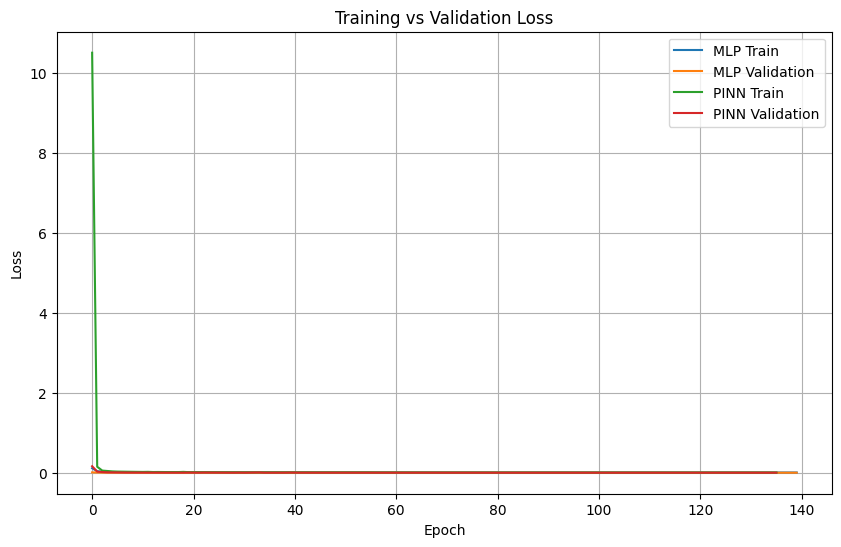

In [44]:
# =========================================================
# TRAINING CURVES
# =========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(

    mlp_history["train_loss"],

    label="MLP Train"
)

plt.plot(

    mlp_history["val_loss"],

    label="MLP Validation"
)

plt.plot(

    pinn_history["train_loss"],

    label="PINN Train"
)

plt.plot(

    pinn_history["val_loss"],

    label="PINN Validation"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.grid(True)

plt.show()

In [45]:
# =========================================================
# COMPARISON DATAFRAME
# =========================================================

comparison_rows = []

for target in TARGET_FEATURES:

    row = {

        "Target": target,

        "MLP_R2":
            mlp_metrics[target]["R2"],

        "PINN_R2":
            pinn_metrics[target]["R2"],

        "MLP_RMSE":
            mlp_metrics[target]["RMSE"],

        "PINN_RMSE":
            pinn_metrics[target]["RMSE"],

        "MLP_MAE":
            mlp_metrics[target]["MAE"],

        "PINN_MAE":
            pinn_metrics[target]["MAE"]
    }

    comparison_rows.append(row)

comparison_df = pd.DataFrame(

    comparison_rows
)

comparison_df

,Target,MLP_R2,PINN_R2,MLP_RMSE,PINN_RMSE,MLP_MAE,PINN_MAE
0,effectiveness,0.992680,0.992317,0.007628,0.007816,0.005668,0.005841
1,pressure_drop_total_Pa,0.997425,0.997075,7380.833557,7867.105186,3627.870850,4448.552246
2,overall_heat_transfer_coefficient_U_W_m2K,0.998700,0.998510,141.727973,151.723600,97.734833,108.659065


In [46]:
# =========================================================
# SAVE COMPARISON CSV
# =========================================================

comparison_df.to_csv(

    "model_comparison_metrics.csv",

    index=False
)

print("Comparison CSV Saved")

Comparison CSV Saved


In [47]:
# =========================================================
# MODEL CONFIG
# =========================================================

model_config = {

    "input_features":
        INPUT_FEATURES,

    "target_features":
        TARGET_FEATURES,

    "input_dim":
        INPUT_DIM,

    "output_dim":
        OUTPUT_DIM,

    "mlp_hidden_dims":
        [512, 256, 128],

    "dropout":
        0.10
}

with open(

    "model_config.json",

    "w"
) as f:

    json.dump(

        model_config,

        f,

        indent=4
    )

print("model_config.json saved")

model_config.json saved


## Tabular Resnet


In [48]:
# =========================================================
# TRANSFORMER INPUT VALIDATION
# =========================================================

print("INPUT DIM:", INPUT_DIM)
print("OUTPUT DIM:", OUTPUT_DIM)

assert INPUT_DIM == 37

print("Transformer input validation passed.")

INPUT DIM: 37
OUTPUT DIM: 3
Transformer input validation passed.


In [49]:
# =========================================================
# FEATURE TOKEN EMBEDDING
# =========================================================

class NumericalFeatureTokenizer(nn.Module):

    def __init__(

        self,

        num_features,

        embedding_dim
    ):

        super().__init__()

        self.num_features = num_features

        self.embedding_dim = embedding_dim

        # =================================================
        # LEARNABLE FEATURE EMBEDDINGS
        # =================================================

        self.weight = nn.Parameter(

            torch.randn(
                num_features,
                embedding_dim
            )
        )

        self.bias = nn.Parameter(

            torch.zeros(
                num_features,
                embedding_dim
            )
        )

    def forward(self, x):

        """
        x shape:
        [batch_size, num_features]
        """

        # =================================================
        # CONVERT EACH FEATURE TO TOKEN
        # =================================================

        x = x.unsqueeze(-1)

        tokens = (

            x * self.weight

            + self.bias
        )

        return tokens

In [50]:
# =========================================================
# TABULAR TRANSFORMER
# =========================================================

class TabularTransformer(nn.Module):

    def __init__(

        self,

        num_features,

        output_dim,

        embedding_dim=64,

        num_heads=8,

        num_layers=4,

        ff_dim=256,

        dropout=0.10
    ):

        super().__init__()

        self.num_features = num_features

        self.embedding_dim = embedding_dim

        # =================================================
        # FEATURE TOKENIZER
        # =================================================

        self.tokenizer = NumericalFeatureTokenizer(

            num_features=num_features,

            embedding_dim=embedding_dim
        )

        # =================================================
        # CLS TOKEN
        # =================================================

        self.cls_token = nn.Parameter(

            torch.randn(
                1,
                1,
                embedding_dim
            )
        )

        # =================================================
        # POSITIONAL EMBEDDING
        # =================================================

        self.positional_embedding = nn.Parameter(

            torch.randn(
                1,
                num_features + 1,
                embedding_dim
            )
        )

        # =================================================
        # TRANSFORMER ENCODER
        # =================================================

        encoder_layer = nn.TransformerEncoderLayer(

            d_model=embedding_dim,

            nhead=num_heads,

            dim_feedforward=ff_dim,

            dropout=dropout,

            activation="gelu",

            batch_first=True,

            norm_first=True
        )

        self.transformer = nn.TransformerEncoder(

            encoder_layer,

            num_layers=num_layers
        )

        # =================================================
        # REGRESSION HEAD
        # =================================================

        self.regressor = nn.Sequential(

            nn.LayerNorm(
                embedding_dim
            ),

            nn.Linear(
                embedding_dim,
                256
            ),

            nn.GELU(),

            nn.Dropout(dropout),

            nn.Linear(
                256,
                128
            ),

            nn.GELU(),

            nn.Dropout(dropout),

            nn.Linear(
                128,
                output_dim
            )
        )

        self._initialize_weights()

    # =====================================================
    # INITIALIZATION
    # =====================================================

    def _initialize_weights(self):

        for module in self.modules():

            if isinstance(module, nn.Linear):

                nn.init.xavier_uniform_(
                    module.weight
                )

                if module.bias is not None:

                    nn.init.zeros_(
                        module.bias
                    )

    # =====================================================
    # FORWARD
    # =====================================================

    def forward(self, x):

        batch_size = x.shape[0]

        # =================================================
        # TOKENIZATION
        # =================================================

        x = self.tokenizer(x)

        # shape:
        # [batch, features, embedding]

        # =================================================
        # CLS TOKEN
        # =================================================

        cls_tokens = self.cls_token.expand(

            batch_size,

            -1,

            -1
        )

        x = torch.cat(

            [cls_tokens, x],

            dim=1
        )

        # =================================================
        # POSITIONAL EMBEDDING
        # =================================================

        x = x + self.positional_embedding

        # =================================================
        # TRANSFORMER
        # =================================================

        x = self.transformer(x)

        # =================================================
        # CLS REPRESENTATION
        # =================================================

        cls_representation = x[:, 0]

        # =================================================
        # REGRESSION
        # =================================================

        output = self.regressor(

            cls_representation
        )

        return output

In [51]:
# =========================================================
# CREATE TABULAR TRANSFORMER
# =========================================================

transformer_model = TabularTransformer(

    num_features=INPUT_DIM,

    output_dim=OUTPUT_DIM,

    embedding_dim=32,

    num_heads=4,

    num_layers=3,

    ff_dim=128,

    dropout=0.10

).to(DEVICE)

print(transformer_model)

TabularTransformer(
  (tokenizer): NumericalFeatureTokenizer()
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (regressor): Sequential(
    (0): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=32, out_features=256, bias=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.1, inplace=False)
    (4): Li

In [52]:
# =========================================================
# LOSS FUNCTION
# =========================================================

transformer_criterion = nn.HuberLoss()

# =========================================================
# OPTIMIZER
# =========================================================

transformer_optimizer = optim.AdamW(

    transformer_model.parameters(),

    lr=5e-4,

    weight_decay=1e-4
)

# =========================================================
# LR SCHEDULER
# =========================================================

transformer_scheduler = optim.lr_scheduler.ReduceLROnPlateau(

    transformer_optimizer,

    mode="min",

    factor=0.5,

    patience=8
)

In [53]:
# =========================================================
# TRAIN TABULAR TRANSFORMER
# =========================================================

transformer_history = train_model(

    model=transformer_model,

    train_loader=train_loader,

    val_loader=val_loader,

    optimizer=transformer_optimizer,

    criterion=transformer_criterion,

    scheduler=transformer_scheduler,

    epochs=60,

    model_name="tabular_transformer_model"
)

BEST MODEL SAVED (Val Loss: 0.026890)
Epoch [1/60] | Train Loss: 0.164142 | Val Loss: 0.026890 | LR: 0.00050000
BEST MODEL SAVED (Val Loss: 0.013259)
Epoch [2/60] | Train Loss: 0.040751 | Val Loss: 0.013259 | LR: 0.00050000
BEST MODEL SAVED (Val Loss: 0.009315)
Epoch [3/60] | Train Loss: 0.029133 | Val Loss: 0.009315 | LR: 0.00050000
BEST MODEL SAVED (Val Loss: 0.007902)
Epoch [4/60] | Train Loss: 0.023788 | Val Loss: 0.007902 | LR: 0.00050000
BEST MODEL SAVED (Val Loss: 0.006464)
Epoch [5/60] | Train Loss: 0.020729 | Val Loss: 0.006464 | LR: 0.00050000
BEST MODEL SAVED (Val Loss: 0.005291)
Epoch [6/60] | Train Loss: 0.018710 | Val Loss: 0.005291 | LR: 0.00050000
BEST MODEL SAVED (Val Loss: 0.005248)
Epoch [7/60] | Train Loss: 0.016944 | Val Loss: 0.005248 | LR: 0.00050000
BEST MODEL SAVED (Val Loss: 0.004620)
Epoch [8/60] | Train Loss: 0.015976 | Val Loss: 0.004620 | LR: 0.00050000
BEST MODEL SAVED (Val Loss: 0.004247)
Epoch [9/60] | Train Loss: 0.015242 | Val Loss: 0.004247 | LR: 0.0

In [54]:
# =========================================================
# SAVE TABULAR TRANSFORMER MODEL
# =========================================================

import torch
import os

save_path = "transformer_model.pth"

torch.save(
    transformer_model.state_dict(),
    save_path
)

print(f"Transformer model saved at: {save_path}")

Transformer model saved at: transformer_model.pth


In [55]:
# =========================================================
# SAVE TRAINING HISTORY
# =========================================================

import json

history_path = "transformer_history.json"

# convert tensors/lists safely
clean_history = {}

for k, v in transformer_history.items():

    if isinstance(v, list):
        clean_history[k] = [float(x) for x in v]
    else:
        clean_history[k] = float(v)

with open(history_path, "w") as f:
    json.dump(clean_history, f, indent=4)

print(f"Training history saved at: {history_path}")

Training history saved at: transformer_history.json


In [56]:
# =========================================================
# UPDATE MODEL CONFIG
# =========================================================

import json

config_path = "model_config.json"

with open(config_path, "r") as f:
    config = json.load(f)

config["transformer"] = {
    "type": "tabular_transformer",
    "embedding_dim": 64,
    "num_heads": 8,
    "num_layers": 4,
    "ff_dim": 256,
    "dropout": 0.1
}

with open(config_path, "w") as f:
    json.dump(config, f, indent=4)

print("Model config updated with transformer settings")

Model config updated with transformer settings


In [57]:
# =========================================================
# PACKAGE ALL ARTIFACTS FOR DEPLOYMENT
# =========================================================

import shutil

deploy_dir = "deployment_transformer"

os.makedirs(deploy_dir, exist_ok=True)

files_to_copy = [

    "transformer_model.pth",
    "x_scaler.pkl",
    "y_scaler.pkl",
    "model_config.json"
]

for file in files_to_copy:

    shutil.copy(file, os.path.join(deploy_dir, file))

print("Deployment package created at:", deploy_dir)

Deployment package created at: deployment_transformer


## Transformer

In [58]:
# =========================================================
# PHYSICS LOSS FOR TRANSFORMER (PITT)
# =========================================================

class PhysicsLossTransformer(nn.Module):

    def __init__(self, y_scaler, alpha=0.02):
        super().__init__()

        self.data_loss = nn.HuberLoss()
        self.alpha = alpha

        # store scaler stats
        self.y_mean = torch.tensor(
            y_scaler.mean_,
            dtype=torch.float32,
            device=DEVICE
        )

        self.y_scale = torch.tensor(
            y_scaler.scale_,
            dtype=torch.float32,
            device=DEVICE
        )

    def inverse_scale(self, y_scaled):
        return y_scaled * self.y_scale + self.y_mean

    def forward(self, preds_scaled, targets_scaled):

        # =========================
        # DATA LOSS (scaled space)
        # =========================
        data_loss = self.data_loss(preds_scaled, targets_scaled)

        # =========================
        # PHYSICAL SPACE
        # =========================
        preds = self.inverse_scale(preds_scaled)

        eff = preds[:, 0]
        dp = preds[:, 1]
        u = preds[:, 2]

        # =========================
        # CONSTRAINT 1: EFFECTIVENESS [0,1]
        # =========================
        eff_penalty = (
            torch.mean(torch.relu(-eff)) +
            torch.mean(torch.relu(eff - 1.0))
        )

        # =========================
        # CONSTRAINT 2: PRESSURE DROP > 0
        # =========================
        dp_penalty = torch.mean(torch.relu(-dp))

        # =========================
        # CONSTRAINT 3: U > 0
        # =========================
        u_penalty = torch.mean(torch.relu(-u))

        # =========================
        # SOFT REGULARIZATION
        # discourage extreme instability
        # =========================
        stability_penalty = torch.mean(torch.abs(torch.diff(preds, dim=0)))

        physics_loss = eff_penalty + dp_penalty + u_penalty + 0.1 * stability_penalty

        total_loss = data_loss + self.alpha * physics_loss

        return total_loss

In [59]:
# =========================================================
# PHYSICS INFORMED TABULAR TRANSFORMER
# =========================================================

class PITT(TabularTransformer):
    """
    Physics-Informed Tabular Transformer
    Inherits full transformer architecture
    """

    def forward(self, x):
        return super().forward(x)

In [60]:
# =========================================================
# CREATE PITT MODEL
# =========================================================

pitt_model = PITT(

    num_features=INPUT_DIM,
    output_dim=OUTPUT_DIM,

    embedding_dim=64,
    num_heads=8,
    num_layers=4,
    ff_dim=256,
    dropout=0.1

).to(DEVICE)

print(pitt_model)

PITT(
  (tokenizer): NumericalFeatureTokenizer()
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (regressor): Sequential(
    (0): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=64, out_features=256, bias=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_featur

In [61]:
# =========================================================
# LOSS FUNCTION
# =========================================================

pitt_criterion = PhysicsLossTransformer(
    y_scaler=y_scaler,
    alpha=0.02
)

# =========================================================
# OPTIMIZER
# =========================================================

pitt_optimizer = optim.AdamW(
    pitt_model.parameters(),
    lr=4e-4,
    weight_decay=1e-4
)

# =========================================================
# SCHEDULER
# =========================================================

pitt_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    pitt_optimizer,
    mode="min",
    factor=0.5,
    patience=10
)

In [62]:
# =========================================================
# TRAIN PITT MODEL (CPU-OPTIMIZED)
# =========================================================

MAX_EPOCHS = 45
PATIENCE = 7
best_val_loss = float('inf')
patience_counter = 0

# Track history
history = {'train_loss': [], 'val_loss': []}

for epoch in range(MAX_EPOCHS):
    # Train
    pitt_model.train()
    train_loss = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(DEVICE), batch_y.to(DEVICE)

        pitt_optimizer.zero_grad()
        preds = pitt_model(batch_x)
        loss = pitt_criterion(preds, batch_y)
        loss.backward()
        pitt_optimizer.step()
        train_loss += loss.item()

    # Validate
    pitt_model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(DEVICE), batch_y.to(DEVICE)
            preds = pitt_model(batch_x)
            loss = pitt_criterion(preds, batch_y)
            val_loss += loss.item()

    # Averages
    train_loss /= len(train_loader)
    val_loss /= len(val_loader)

    # Scheduler step
    pitt_scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    print(f"Epoch {epoch+1:02d} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | LR: {pitt_optimizer.param_groups[0]['lr']:.6f}")

    # Early Stopping Logic
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(pitt_model.state_dict(), "pitt_model.pth")
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

print("Training Complete. Best model saved as 'pitt_model.pth'")

Epoch 01 | Train: 10.6858 | Val: 0.6525 | LR: 0.000400
Epoch 02 | Train: 4.3001 | Val: 0.4943 | LR: 0.000400
Epoch 03 | Train: 2.9140 | Val: 0.4249 | LR: 0.000400
Epoch 04 | Train: 2.3422 | Val: 0.3989 | LR: 0.000400
Epoch 05 | Train: 2.0329 | Val: 0.3892 | LR: 0.000400
Epoch 06 | Train: 1.7943 | Val: 0.4032 | LR: 0.000400
Epoch 07 | Train: 1.6304 | Val: 0.3760 | LR: 0.000400
Epoch 08 | Train: 1.5258 | Val: 0.3714 | LR: 0.000400
Epoch 09 | Train: 1.4225 | Val: 0.3687 | LR: 0.000400
Epoch 10 | Train: 1.3364 | Val: 0.3690 | LR: 0.000400
Epoch 11 | Train: 1.2683 | Val: 0.3718 | LR: 0.000400
Epoch 12 | Train: 1.1941 | Val: 0.3643 | LR: 0.000400
Epoch 13 | Train: 1.1341 | Val: 0.3627 | LR: 0.000400
Epoch 14 | Train: 1.0700 | Val: 0.3636 | LR: 0.000400
Epoch 15 | Train: 1.0238 | Val: 0.3604 | LR: 0.000400
Epoch 16 | Train: 0.9607 | Val: 0.3561 | LR: 0.000400
Epoch 17 | Train: 0.9175 | Val: 0.3588 | LR: 0.000400
Epoch 18 | Train: 0.8734 | Val: 0.3485 | LR: 0.000400
Epoch 19 | Train: 0.8358 | 

# **Visualizations**

In [63]:
# =========================================================
# LOAD BEST CHECKPOINTS
# =========================================================

mlp_model.load_state_dict(torch.load("mlp_model.pth", map_location=DEVICE))
pinn_model.load_state_dict(torch.load("pinn_model.pth", map_location=DEVICE))
transformer_model.load_state_dict(torch.load("tabular_transformer_model.pth", map_location=DEVICE))
pitt_model.load_state_dict(torch.load("pitt_model.pth", map_location=DEVICE))

mlp_model.eval()
pinn_model.eval()
transformer_model.eval()
pitt_model.eval()

print("All models loaded successfully.")

All models loaded successfully.


In [64]:
# =========================================================
# EVALUATION FUNCTION
# =========================================================

def evaluate_all_models(model, X_test_tensor, y_test_scaled, y_scaler, name):

    model.eval()

    with torch.no_grad():
        preds_scaled = model(X_test_tensor).cpu().numpy()

    preds = y_scaler.inverse_transform(preds_scaled)
    true = y_scaler.inverse_transform(y_test_scaled)

    results = {}

    for i, target in enumerate(TARGET_FEATURES):

        y_t = true[:, i]
        y_p = preds[:, i]

        mae = mean_absolute_error(y_t, y_p)
        rmse = np.sqrt(mean_squared_error(y_t, y_p))
        r2 = r2_score(y_t, y_p)

        eps = 1e-8
        mape = np.mean(np.abs((y_t - y_p) / (np.abs(y_t) + eps))) * 100

        results[target] = {
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2,
            "MAPE": mape
        }

    print("\n" + "="*60)
    print(f"{name} RESULTS")
    print("="*60)

    for k, v in results.items():
        print(f"\n{k}")
        for mk, mv in v.items():
            print(f"{mk}: {mv:.6f}")

    return results, preds, true

In [65]:
# =========================================================
# RUN EVALUATION
# =========================================================

mlp_results, mlp_preds, y_true = evaluate_all_models(
    mlp_model, X_test_tensor, y_test_scaled, y_scaler, "MLP"
)

pinn_results, pinn_preds, _ = evaluate_all_models(
    pinn_model, X_test_tensor, y_test_scaled, y_scaler, "PINN"
)

transformer_results, transformer_preds, _ = evaluate_all_models(
    transformer_model, X_test_tensor, y_test_scaled, y_scaler, "TRANSFORMER"
)

pitt_results, pitt_preds, _ = evaluate_all_models(
    pitt_model, X_test_tensor, y_test_scaled, y_scaler, "PITT"
)


MLP RESULTS

effectiveness
MAE: 0.005668
RMSE: 0.007628
R2: 0.992680
MAPE: 0.677067

pressure_drop_total_Pa
MAE: 3627.870850
RMSE: 7380.833557
R2: 0.997425
MAPE: 6.631343

overall_heat_transfer_coefficient_U_W_m2K
MAE: 97.734833
RMSE: 141.727973
R2: 0.998700
MAPE: 1.730320

PINN RESULTS

effectiveness
MAE: 0.005841
RMSE: 0.007816
R2: 0.992317
MAPE: 0.698023

pressure_drop_total_Pa
MAE: 4448.552246
RMSE: 7867.105186
R2: 0.997075
MAPE: 12.251642

overall_heat_transfer_coefficient_U_W_m2K
MAE: 108.659065
RMSE: 151.723600
R2: 0.998510
MAPE: 1.991803

TRANSFORMER RESULTS

effectiveness
MAE: 0.006116
RMSE: 0.008124
R2: 0.991698
MAPE: 0.731009

pressure_drop_total_Pa
MAE: 4213.899902
RMSE: 8250.793416
R2: 0.996783
MAPE: 6.719576

overall_heat_transfer_coefficient_U_W_m2K
MAE: 111.978859
RMSE: 158.526516
R2: 0.998374
MAPE: 2.034984

PITT RESULTS

effectiveness
MAE: 0.010899
RMSE: 0.014584
R2: 0.973247
MAPE: 1.329476

pressure_drop_total_Pa
MAE: 91855.070312
RMSE: 145520.083562
R2: -0.000794
M

In [66]:
# =========================================================
# BUILD COMPARISON TABLE
# =========================================================

rows = []

for i, target in enumerate(TARGET_FEATURES):

    rows.append({
        "Target": target,

        "MLP_R2": mlp_results[target]["R2"],
        "PINN_R2": pinn_results[target]["R2"],
        "TRANSFORMER_R2": transformer_results[target]["R2"],
        "PITT_R2": pitt_results[target]["R2"],

        "MLP_RMSE": mlp_results[target]["RMSE"],
        "PINN_RMSE": pinn_results[target]["RMSE"],
        "TRANSFORMER_RMSE": transformer_results[target]["RMSE"],
        "PITT_RMSE": pitt_results[target]["RMSE"]
    })

comparison_df = pd.DataFrame(rows)

comparison_df

,Target,MLP_R2,PINN_R2,TRANSFORMER_R2,PITT_R2,MLP_RMSE,PINN_RMSE,TRANSFORMER_RMSE,PITT_RMSE
0,effectiveness,0.992680,0.992317,0.991698,0.973247,0.007628,0.007816,0.008124,0.014584
1,pressure_drop_total_Pa,0.997425,0.997075,0.996783,-0.000794,7380.833557,7867.105186,8250.793416,145520.083562
2,overall_heat_transfer_coefficient_U_W_m2K,0.998700,0.998510,0.998374,-0.023700,141.727973,151.723600,158.526516,3977.181414


In [67]:
comparison_df.to_csv("final_model_comparison.csv", index=False)
print("Saved: final_model_comparison.csv")

Saved: final_model_comparison.csv


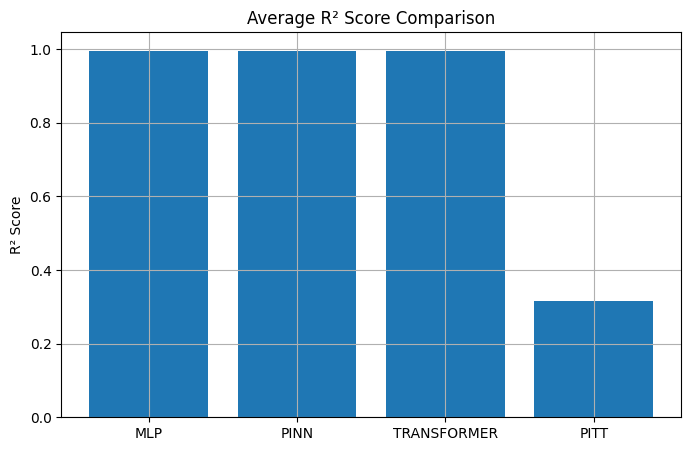

In [68]:
import matplotlib.pyplot as plt

models = ["MLP", "PINN", "TRANSFORMER", "PITT"]

avg_r2 = [
    np.mean([mlp_results[t]["R2"] for t in TARGET_FEATURES]),
    np.mean([pinn_results[t]["R2"] for t in TARGET_FEATURES]),
    np.mean([transformer_results[t]["R2"] for t in TARGET_FEATURES]),
    np.mean([pitt_results[t]["R2"] for t in TARGET_FEATURES])
]

plt.figure(figsize=(8,5))
plt.bar(models, avg_r2)
plt.title("Average R² Score Comparison")
plt.ylabel("R² Score")
plt.grid(True)
plt.show()

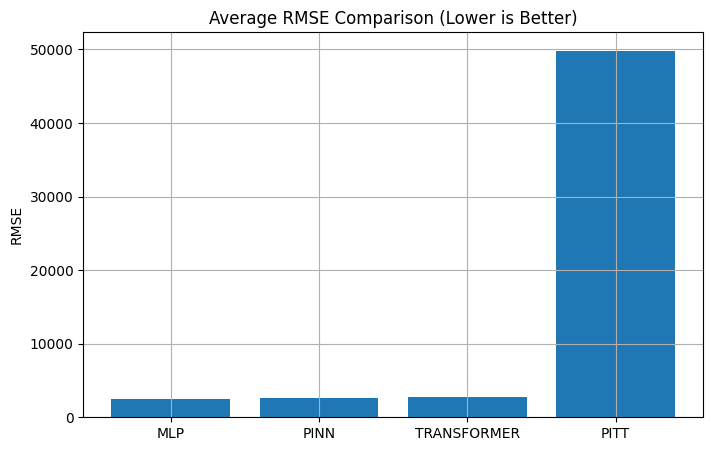

In [69]:
avg_rmse = [
    np.mean([mlp_results[t]["RMSE"] for t in TARGET_FEATURES]),
    np.mean([pinn_results[t]["RMSE"] for t in TARGET_FEATURES]),
    np.mean([transformer_results[t]["RMSE"] for t in TARGET_FEATURES]),
    np.mean([pitt_results[t]["RMSE"] for t in TARGET_FEATURES])
]

plt.figure(figsize=(8,5))
plt.bar(models, avg_rmse)
plt.title("Average RMSE Comparison (Lower is Better)")
plt.ylabel("RMSE")
plt.grid(True)
plt.show()

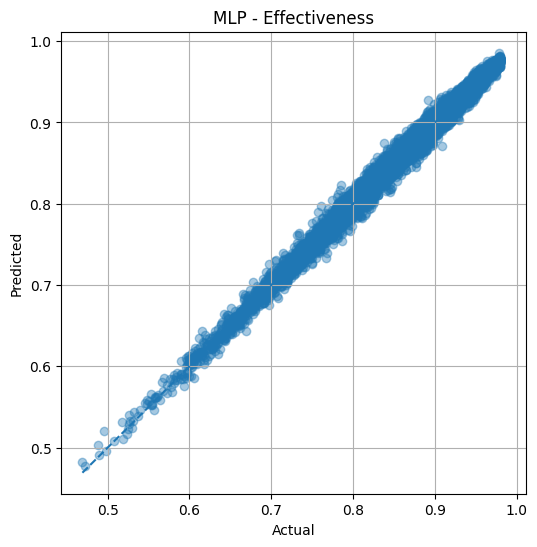

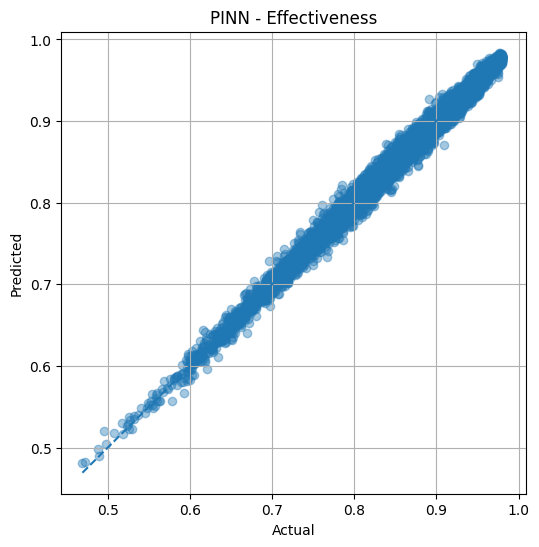

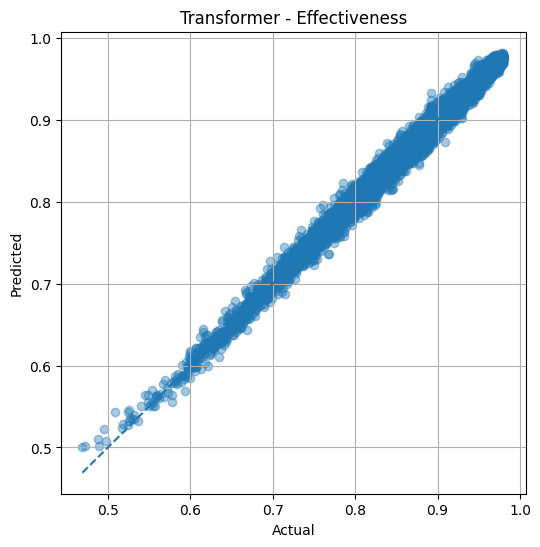

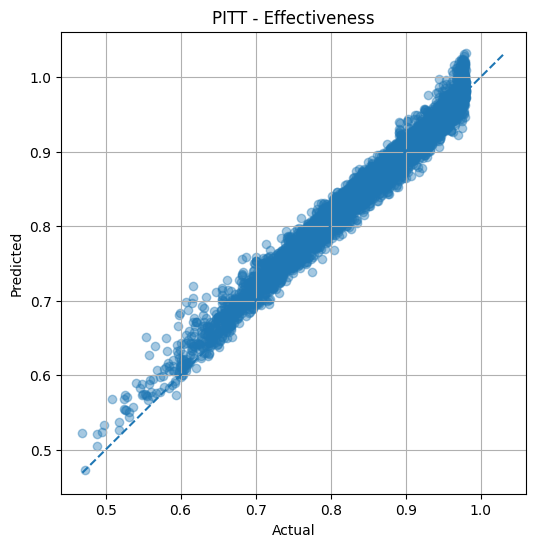

In [70]:
def plot_predictions(true, pred, title):

    plt.figure(figsize=(6,6))

    plt.scatter(true, pred, alpha=0.4)

    min_v = min(true.min(), pred.min())
    max_v = max(true.max(), pred.max())

    plt.plot([min_v, max_v], [min_v, max_v], "--")

    plt.title(title)
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.grid(True)
    plt.show()


# Example for effectiveness
i = 0

plot_predictions(
    y_true[:, i],
    mlp_preds[:, i],
    "MLP - Effectiveness"
)

plot_predictions(
    y_true[:, i],
    pinn_preds[:, i],
    "PINN - Effectiveness"
)

plot_predictions(
    y_true[:, i],
    transformer_preds[:, i],
    "Transformer - Effectiveness"
)

plot_predictions(
    y_true[:, i],
    pitt_preds[:, i],
    "PITT - Effectiveness"
)

In [71]:
# =========================================================
# SAVE MODELS
# =========================================================

torch.save(mlp_model.state_dict(), "mlp_model.pth")
torch.save(pinn_model.state_dict(), "pinn_model.pth")
torch.save(transformer_model.state_dict(), "tabular_transformer_model.pth")
torch.save(pitt_model.state_dict(), "pitt_model.pth")

print("All models saved for Streamlit deployment.")

All models saved for Streamlit deployment.
